# Customer Churn Prediction

## Phase 2 - Data Cleaning & Validation

### Objective

The objective of this notebook is to perform data quality assessment and preprocessing before exploratory data analysis and machine learning.

This notebook includes:

- Importing data from MySQL
- Data quality assessment
- Missing value analysis
- Duplicate detection
- Statistical summary
- Outlier analysis
- Distribution analysis
- Correlation analysis

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset from MySQL

In [2]:
connection=mysql.connector.connect(host="localhost", user='root', password='<Your Password>',database="Customer_churn")

print("Connected Successfully!")

Connected Successfully!


In [3]:
query= "select * from customers"
df=pd.read_sql(query,connection)

C:\Users\nihil\AppData\Local\Temp\ipykernel_5696\233691050.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,connection)


## Preview Dataset

In [4]:
df.head()

,customerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


## Dataset Shape

In [5]:
df.shape

(100000, 9)

## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   customerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


### Observation

- Dataset contains **100,000 records**.
- There are **9 columns**.
- Numerical and categorical data types are correctly identified.
- No missing values are present.

## Data Type Validation

The data types of all columns were reviewed to ensure they are appropriate for analysis and machine learning.

### Data Type Summary

| Column | Data Type | Status |
|---------|-----------|--------|
| customerID | int64 | ✅ Correct |
| Age | int64 | ✅ Correct |
| Gender | object | ✅ Correct |
| Tenure | int64 | ✅ Correct |
| MonthlyCharges | float64 | ✅ Correct |
| Contract | object | ✅ Correct |
| PaymentMethod | object | ✅ Correct |
| TotalCharges | float64 | ✅ Correct |
| Churn | object | ✅ Correct (Target Variable) |

### Observations

- The dataset contains **100,000 customer records** and **9 features**.
- No missing values were identified in any column.
- Numerical variables (`Age`, `Tenure`, `MonthlyCharges`, and `TotalCharges`) are stored using appropriate numeric data types.
- Categorical variables (`Gender`, `Contract`, `PaymentMethod`, and `Churn`) are correctly stored as object data types.
- `customerID` is a unique identifier and will be excluded from model training since it does not contribute to predicting customer churn.

### Conclusion

The dataset is well structured, and no data type conversions are required. The next step is to investigate the negative values detected in the `TotalCharges` column and perform additional data quality checks before exploratory data analysis.

## Statistical Summary

In [7]:
df.describe()

,customerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


## Numerical Feature Summary

The descriptive statistics provide an overview of the numerical variables in the dataset.

### Customer ID

- Customer IDs range from **1 to 100,000**.
- This column serves as a unique identifier and will not be used as a predictive feature during model training.

### Age

- Minimum Age: **18**
- Maximum Age: **80**
- Average Age: **49.03 years**
- Median Age: **49 years**

**Observation:**
The customer age distribution appears balanced around the median, suggesting no significant skewness.

---

### Tenure

- Minimum Tenure: **1 month**
- Maximum Tenure: **72 months**
- Average Tenure: **36.53 months**
- Median Tenure: **37 months**

**Observation:**
Customers have been with the company for an average of approximately three years.

---

### Monthly Charges

- Minimum Monthly Charge: **10.00**
- Maximum Monthly Charge: **150.00**
- Average Monthly Charge: **79.97**
- Median Monthly Charge: **80.00**

**Observation:**
The average and median are nearly identical, indicating that Monthly Charges are approximately symmetrically distributed.

---

### Total Charges

- Minimum Total Charges: **-118.43**
- Maximum Total Charges: **10,831.46**
- Average Total Charges: **2,926.14**
- Median Total Charges: **2,268.06**

**Observation:**
The presence of negative values in Total Charges indicates a data quality issue that requires further investigation before machine learning.

---

## Initial Data Quality Assessment

- No obvious anomalies are observed in Age, Tenure, or Monthly Charges.
- Negative values in Total Charges are inconsistent with business expectations and will be investigated during the data cleaning phase.
- CustomerID will be excluded from predictive modelling as it is an identifier rather than a meaningful feature.

## Categorical Summary

In [8]:
df.describe(include='object')

,Gender,Contract,PaymentMethod,Churn
count,100000,100000,100000,100000
unique,3,3,4,2
top,Female,Month-to-month,Electronic check,No
freq,48256,54915,34892,66856


## Categorical Feature Summary

The dataset contains four categorical features:

- **Gender** has 3 unique categories, with **Female** being the most frequent (48,256 customers).
- **Contract** has 3 contract types, with **Month-to-month** being the most common (54,915 customers).
- **PaymentMethod** contains 4 payment methods, with **Electronic check** used by the largest number of customers (34,892).
- **Churn** is the target variable with two classes:
  - **No:** 66,856 customers
  - **Yes:** 33,144 customers

### Initial Observations

- The dataset contains multiple categorical variables that will require encoding before machine learning.
- The target variable is moderately imbalanced (approximately 67% No vs 33% Yes), which should be considered during model evaluation.
- The high proportion of month-to-month contracts may indicate an area for further churn analysis.

## Missing Value Analysis

In [9]:
df.isnull().sum()

customerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

## Missing Value Analysis

A missing value assessment was performed on all features in the dataset.

### Results

| Feature | Missing Values |
|----------|---------------:|
| CustomerID | 0 |
| Age | 0 |
| Gender | 0 |
| Tenure | 0 |
| MonthlyCharges | 0 |
| Contract | 0 |
| PaymentMethod | 0 |
| TotalCharges | 0 |
| Churn | 0 |

### Observation

- No missing values were found in any of the columns.
- The dataset is complete and does not require missing value imputation.
- This reduces preprocessing effort and allows the analysis to proceed directly to data quality validation and feature analysis.

### Next Step

The next step is to check for duplicate records and investigate any remaining data quality issues, such as the negative values identified in the `TotalCharges` column.

## Duplicate Record Check

In [10]:
df.duplicated().sum()

0

### Observation

- No duplicate records were identified in the dataset.
- Each customer record is unique, ensuring that the analysis and machine learning models will not be biased by repeated observations.


## Negative TotalCharges Analysis

In [11]:
df[df['TotalCharges']<0]

,customerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
667,668,56,Male,2,14.58,Two year,Electronic check,-13.55,No
1019,1020,28,Female,5,11.13,Month-to-month,Credit card,-80.24,Yes
1337,1338,23,Female,4,25.92,Month-to-month,Bank transfer,-19.18,Yes
2090,2091,74,Male,3,26.68,Month-to-month,Mailed check,-22.84,Yes
2407,2408,73,Female,1,33.34,Month-to-month,Electronic check,-18.84,Yes
...,...,...,...,...,...,...,...,...,...
99065,99066,71,Female,1,32.29,One year,Mailed check,-23.40,No
99442,99443,38,Female,4,14.29,One year,Electronic check,-36.69,No
99606,99607,53,Male,2,31.01,Month-to-month,Mailed check,-50.99,Yes
99648,99649,48,Male,3,21.47,Two year,Electronic check,-10.15,No


In [12]:
df[df['TotalCharges']<0].shape

(265, 9)

In [13]:
negative_count = (df['TotalCharges']<0).sum()
percentage = (negative_count/len(df))*100
print(f"Negative Totalcharges: {negative_count}")
print(f"Percentage : {percentage:.2f}%")
      

Negative Totalcharges: 265
Percentage : 0.27%


## Investigation of Negative TotalCharges

A data quality check was performed to identify invalid values in the `TotalCharges` column.

### Results

- Negative TotalCharges: **265**
- Percentage of Dataset: **0.27%**

### Business Observation

- Only **0.27%** of the customer records contain negative total charges.
- Since customer billing amounts are generally expected to be non-negative, these records require further investigation.
- The issue affects a very small proportion of the dataset, making it easier to inspect before deciding on an appropriate treatment.

### Recommendation

The negative values will be analysed further to determine whether they are:
- Data entry errors
- Refund or credit adjustments
- Synthetic data generation artifacts

The final cleaning strategy will be decided after examining these records.

In [14]:
df[df['TotalCharges']<0].describe()

,customerID,Age,Tenure,MonthlyCharges,TotalCharges
count,265.000000,265.000000,265.000000,265.000000,265.000000
mean,50910.143396,48.803774,1.905660,30.302830,-28.026679
std,28602.056782,18.186096,1.312298,22.486272,23.562107
min,668.000000,18.000000,1.000000,10.000000,-118.430000
25%,27336.000000,33.000000,1.000000,14.710000,-39.910000
50%,47571.000000,48.000000,1.000000,22.640000,-20.700000
75%,76409.000000,63.000000,2.000000,37.020000,-11.260000
max,99744.000000,80.000000,8.000000,127.990000,-0.020000


### Key Findings

- Negative `TotalCharges` occur almost exclusively among customers with **low tenure (1–8 months)**.
- `MonthlyCharges` remain positive for all affected customers.
- No unusual age distribution was observed.
- The negative values represent a very small proportion of the dataset (0.27%).

### Business Interpretation

These negative values are unlikely to represent actual customer spending. They may indicate billing adjustments, promotional credits, refunds, or artefacts introduced during synthetic data generation.

### Decision

The affected records will **not** be removed immediately. They will be retained during exploratory analysis and reassessed before machine learning to determine the most appropriate treatment.

In [15]:
df[df['TotalCharges']<0]['Contract'].value_counts()

Contract
Month-to-month    140
One year           68
Two year           57
Name: count, dtype: int64

In [16]:
df[df['TotalCharges']<0]['PaymentMethod'].value_counts()

PaymentMethod
Electronic check    87
Mailed check        72
Credit card         53
Bank transfer       53
Name: count, dtype: int64

In [17]:
df[df['TotalCharges']<0]['Gender'].value_counts()

Gender
Female    128
Male      125
Other      12
Name: count, dtype: int64

In [18]:
df[df['TotalCharges']<0]['Churn'].value_counts()

Churn
Yes    160
No     105
Name: count, dtype: int64

In [19]:
negative_churn = df[df["TotalCharges"] < 0]["Churn"].value_counts(normalize=True) * 100
negative_churn

Churn
Yes    60.377358
No     39.622642
Name: proportion, dtype: float64

## Root Cause Analysis of Negative TotalCharges

The negative values in `TotalCharges` were analysed across multiple business dimensions.

### Findings

**Contract Type**
- 52.8% of affected customers have Month-to-month contracts.
- The remaining records are distributed across One-year and Two-year contracts.

**Payment Method**
- Negative values occur across all payment methods.
- No payment method appears to be responsible for the anomaly.

**Gender**
- The distribution is balanced across genders.
- No gender-specific pattern was identified.

**Churn Status**
- Approximately 60% of affected customers have churned.
- This is notably higher than the overall dataset churn rate (33.14%).

### Overall Interpretation

The negative `TotalCharges` values are primarily associated with customers who:
- Have very low tenure (1–8 months)
- Commonly use Month-to-month contracts
- Exhibit a higher churn rate than the overall customer population

The anomaly does not appear to be linked to payment method or gender.

### Data Cleaning Decision

Since only **265 records (0.27%)** are affected and a consistent business pattern exists, these records will be retained during exploratory analysis. Before model training, an appropriate treatment—such as removal, correction, or imputation—will be selected and documented with a clear justification.

## Remove Identifier Column

In [20]:
df.drop('customerID', axis=1, inplace=True)
df.head()

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,46,Female,10,52.47,One year,Electronic check,537.88,No
3,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


## Removing Identifier Column

The `customerID` column is a unique identifier for each customer.

Since it does not contain predictive information about customer churn, it was removed from the dataset before further analysis.

## Outlier Analysis

In [21]:
numerical_cols=df.select_dtypes(include='number')
numerical_cols.head()

,Age,Tenure,MonthlyCharges,TotalCharges
0,56,68,147.58,10052.03
1,69,32,22.54,686.78
2,46,10,52.47,537.88
3,32,22,109.67,2390.04
4,60,54,130.98,7081.28


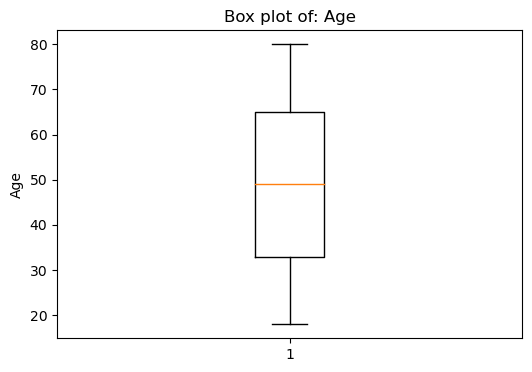

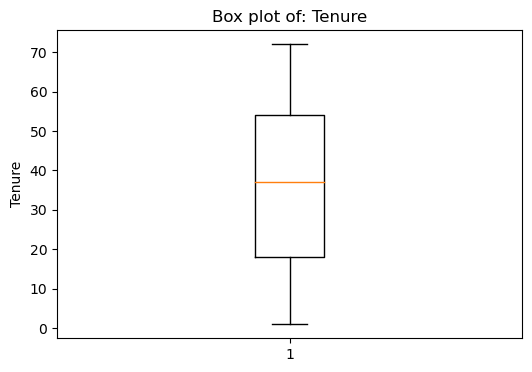

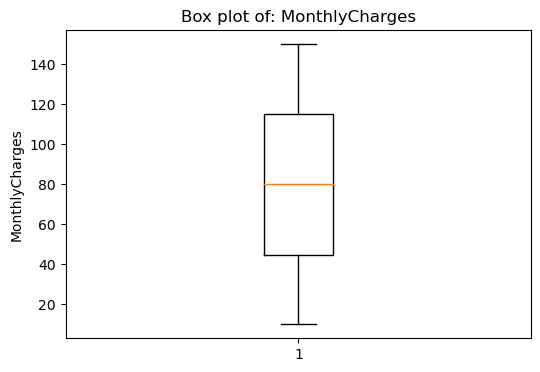

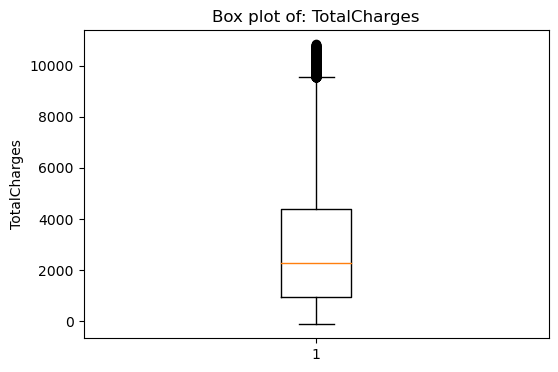

In [22]:
for i in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[i])
    plt.title(f"Box plot of: {i}")
    plt.ylabel(i)
    plt.show()

In [23]:
df[df['TotalCharges']>9500][['Tenure','MonthlyCharges','TotalCharges']].head(10)

,Tenure,MonthlyCharges,TotalCharges
0,68,147.58,10052.03
22,71,137.43,9770.71
28,72,147.64,10585.50
344,66,148.17,9655.67
381,72,135.51,9741.19
511,72,144.68,10359.33
541,68,149.30,10223.91
767,70,143.58,10022.13
768,70,136.22,9550.61
848,72,145.85,10539.97


## Outlier Analysis

Boxplots were generated for all numerical variables to identify potential outliers.

### Findings

- No significant outliers were observed in `Age`, `Tenure`, or `MonthlyCharges`.
- `TotalCharges` contains several upper-end outliers.

### Business Interpretation

`TotalCharges` is a cumulative feature calculated over the customer's subscription period. Customers with longer tenure and higher monthly charges naturally accumulate larger total charges.

Therefore, these values are considered valid business observations rather than data errors.

### Decision

The outliers in `TotalCharges` will be retained because they represent genuine customer behaviour and may contain valuable information for predictive modelling.

## Distribution Analysis

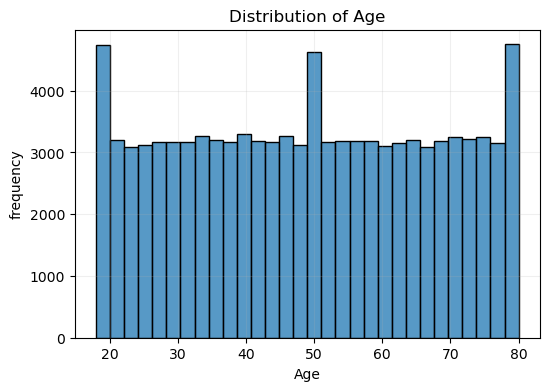

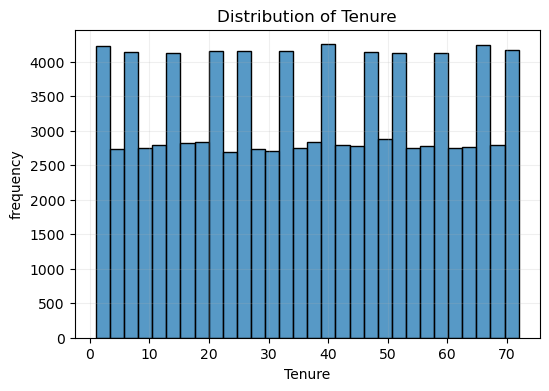

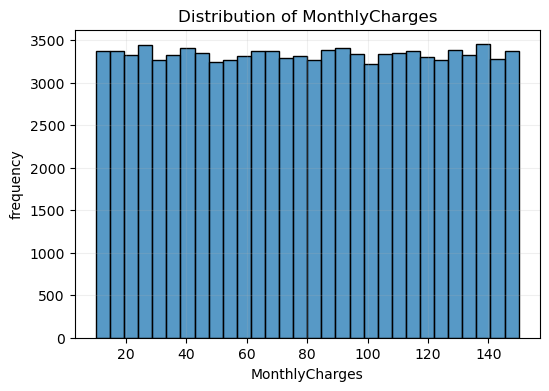

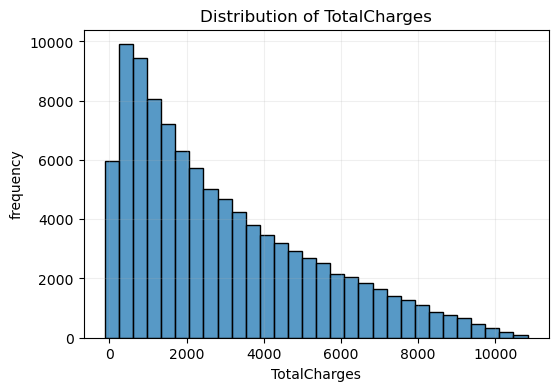

In [24]:
for i in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],bins=30)
    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.ylabel('frequency')
    plt.grid(alpha=0.2)
    plt.show()

## Distribution Analysis

Histograms were generated for all numerical variables to understand their distributions before exploratory analysis and model development.

### Age

- The age distribution is approximately uniform between 18 and 80 years.
- No significant skewness is observed.
- Customers from different age groups are well represented.

### Tenure

- Customer tenure is distributed across the full range of 1 to 72 months.
- Both new and long-term customers are present in similar proportions.
- No major skewness is observed.

### MonthlyCharges

- Monthly charges are evenly distributed between ₹10 and ₹150.
- The dataset contains customers subscribed to various pricing plans.
- No unusual concentration of values is observed.

### TotalCharges

- The distribution is positively (right) skewed.
- Most customers have lower cumulative charges.
- A smaller group of long-term customers have substantially higher total charges.
- This behaviour is expected because TotalCharges accumulates over time.

### Conclusion

The numerical variables exhibit realistic business distributions. No transformations are immediately required. The right skew in TotalCharges represents genuine customer behaviour rather than data quality issues.

## Correlation Analysis

In [25]:
corr=df.corr(numeric_only=True)
corr

,Age,Tenure,MonthlyCharges,TotalCharges
Age,1.000000,0.007915,0.004835,0.008958
Tenure,0.007915,1.000000,0.005976,0.700959
MonthlyCharges,0.004835,0.005976,1.000000,0.623864
TotalCharges,0.008958,0.700959,0.623864,1.000000


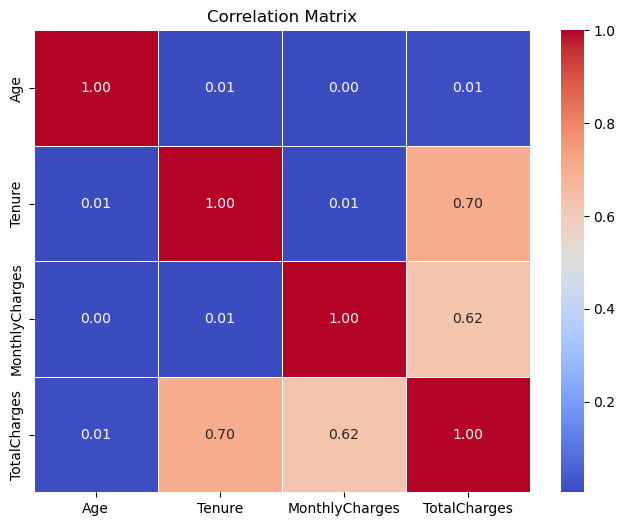

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Correlation Analysis

A correlation matrix was generated to measure the strength of linear relationships between numerical variables.

## Key Findings

### Age

- Age has almost no correlation with Tenure, MonthlyCharges, or TotalCharges.
- Customer age appears to be independent of subscription duration and billing behaviour.

### Tenure and TotalCharges

- A strong positive correlation (**0.70**) exists between Tenure and TotalCharges.
- Customers with longer subscriptions naturally accumulate higher total charges.

### MonthlyCharges and TotalCharges

- A moderate positive correlation (**0.62**) exists between MonthlyCharges and TotalCharges.
- Customers paying higher monthly fees generally accumulate larger total charges over time.

### Tenure and MonthlyCharges

- The correlation is close to zero (**0.01**).
- Subscription duration does not determine the monthly subscription cost.

## Business Conclusion

The observed relationships are consistent with expected business behaviour. No unexpected correlations or multicollinearity issues were identified. The dataset is suitable for feature engineering and predictive modelling.

In [27]:
df=df[df['TotalCharges']>=0]

In [28]:
df.shape

(99735, 8)

In [29]:
df.to_csv("customer_churn_cleaned.csv", index=False)